<a href="https://colab.research.google.com/github/marinamaer123/new_test/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22HW_16_2_%D0%9F%D1%80%D0%BE%D0%B3%D0%BD%D0%BE%D0%B7%D1%83%D0%B2%D0%B0%D0%BD%D0%BD%D1%8F_%D0%BA%D1%80%D0%B5%D0%B4%D0%B8%D1%82%D0%BD%D0%BE%D0%B3%D0%BE_%D1%80%D0%B8%D0%B7%D0%B8%D0%BA%D1%83_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Прогнозування кредитного ризику

## Мета завдання
Застосувати знання з лекції для побудови моделі логістичної регресії, що прогнозує ймовірність дефолту за кредитом, іншими словами, що людина не поверне кредит. Ви пройдете весь цикл: від дослідницького аналізу до оцінки якості класифікаційної моделі.

## Опис датасету
**Credit Risk Dataset** містить інформацію про 32,000+ позичальників з такими параметрами:
- **person_age**: Вік позичальника
- **person_income**: Річний дохід
- **person_home_ownership**: Тип володіння житлом
- **person_emp_length**: Стаж роботи (в роках)
- **loan_intent**: Мета кредиту
- **loan_grade**: Кредитний рейтинг (A - кращий, F - гірший)
- **loan_amnt**: Сума кредиту
- **loan_int_rate**: Процентна ставка
- **loan_status**: Статус кредиту (0 = сплачено, 1 = дефолт) - **цільова змінна**
- **loan_percent_income**: Відношення кредиту до доходу
- **cb_person_default_on_file**: Історія дефолтів (Y/N)
- **cb_person_cred_hist_length**: Довжина кредитної історії

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `credit_risk_dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)
5. Перевірте розподіл цільової змінної (відсотк даних для кожного класу)

Дайте висновок, це задача збалансованої чи незбалансованої класифікації.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/credit_risk_dataset.csv')

In [3]:
data.shape

(32581, 12)

In [4]:
data.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
data['loan_status'].value_counts(normalize = True)*100

,proportion
loan_status,
0,78.183604
1,21.816396



---

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
2. Проаналізуйте розподіл числових змінних.
3. Знайдіть та обробіть викиди в колонці person_income з допомогою [Interquartile range](https://uk.wikipedia.org/wiki/%D0%9C%D1%96%D0%B6%D0%BA%D0%B2%D0%B0%D1%80%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D1%80%D0%BE%D0%B7%D0%BC%D0%B0%D1%85).
4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.
5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.


In [7]:
missing_data = data.isnull().sum()
missing_percent = (missing_data/len(data))*100
missing_percent

,0
person_age,0.000000
person_income,0.000000
person_home_ownership,0.000000
person_emp_length,2.747000
loan_intent,0.000000
loan_grade,0.000000
loan_amnt,0.000000
loan_int_rate,9.563856
loan_status,0.000000
loan_percent_income,0.000000


In [8]:
data['person_emp_length'] = data['person_emp_length'].fillna(data['person_emp_length'].median())

In [9]:
data['loan_int_rate'] = data['loan_int_rate'].fillna(data['loan_int_rate'].median())

In [10]:
data.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.767994,9589.371106,11.009620,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.087372,6322.086646,3.081611,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.110000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [11]:
Q1 = data['person_income'].quantile(0.25)
Q3 = data['person_income'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
data = data[(data['person_income'] >= lower) & (data['person_income'] <= upper)]

In [12]:
cat_col = data.select_dtypes(include='object').columns
cat_col

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')

In [13]:
for col in cat_col:
  print(f'\nColumn: {col}')
  print(data[col].value_counts())


Column: person_home_ownership
person_home_ownership
RENT        16102
MORTGAGE    12426
OWN          2469
OTHER         100
Name: count, dtype: int64

Column: loan_intent
loan_intent
EDUCATION            6201
MEDICAL              5846
VENTURE              5445
PERSONAL             5260
DEBTCONSOLIDATION    4955
HOMEIMPROVEMENT      3390
Name: count, dtype: int64

Column: loan_grade
loan_grade
A    10343
B     9924
C     6191
D     3459
E      899
F      221
G       60
Name: count, dtype: int64

Column: cb_person_default_on_file
cb_person_default_on_file
N    25626
Y     5471
Name: count, dtype: int64


In [14]:
for col in cat_col:
  print(f'\nColumn: {col}')
  print(data.groupby(col)['loan_status'].agg(['count','mean']).sort_values('mean',ascending=False))


Column: person_home_ownership
                       count      mean
person_home_ownership                 
OTHER                    100  0.320000
RENT                   16102  0.319463
MORTGAGE               12426  0.128360
OWN                     2469  0.077764

Column: loan_intent
                   count      mean
loan_intent                       
DEBTCONSOLIDATION   4955  0.290817
HOMEIMPROVEMENT     3390  0.271976
MEDICAL             5846  0.271468
PERSONAL            5260  0.206084
EDUCATION           6201  0.176101
VENTURE             5445  0.153719

Column: loan_grade
            count      mean
loan_grade                 
G              60  0.983333
F             221  0.719457
E             899  0.656285
D            3459  0.600752
C            6191  0.214990
B            9924  0.168984
A           10343  0.103355

Column: cb_person_default_on_file
                           count      mean
cb_person_default_on_file                 
Y                           5471  0.38585

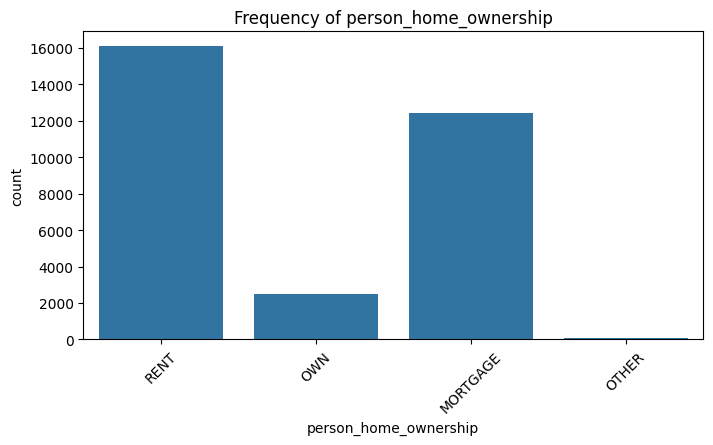

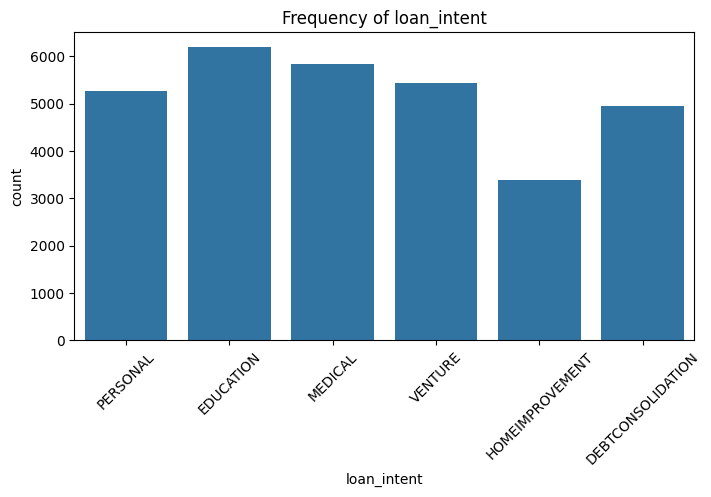

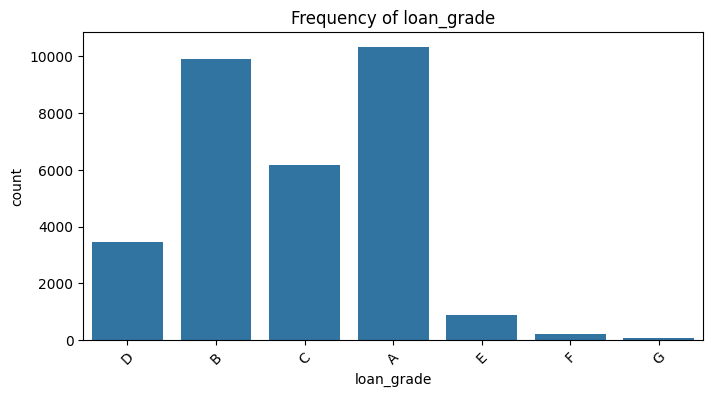

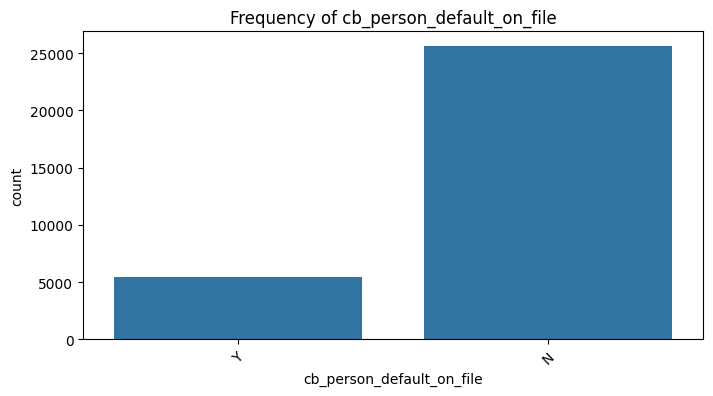

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in cat_col:
    plt.figure(figsize=(8,4))
    sns.countplot(data=data, x=col)
    plt.xticks(rotation=45)
    plt.title(f'Frequency of {col}')
    plt.show()

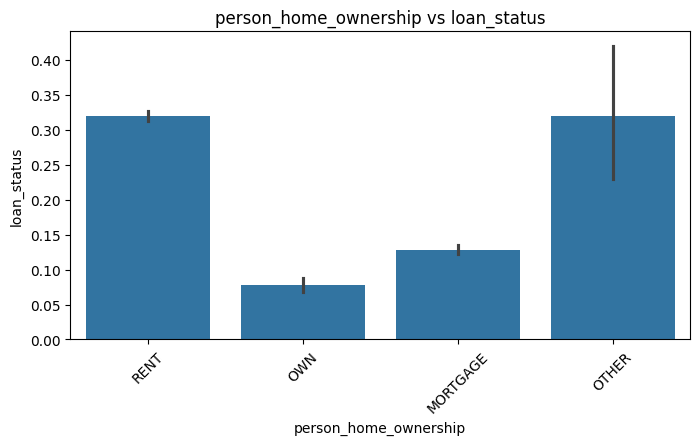

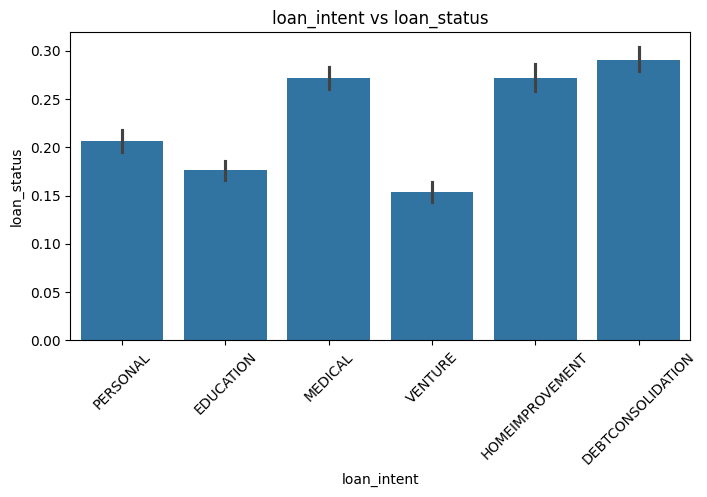

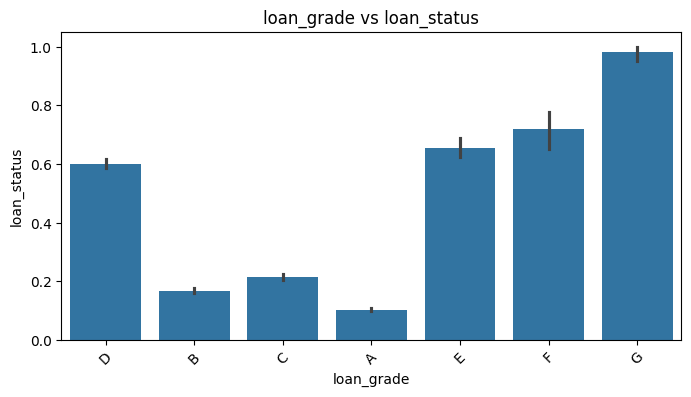

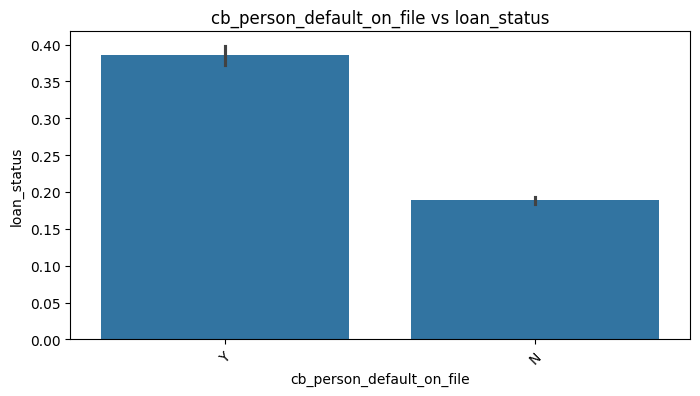

In [16]:
for col in cat_col:
    plt.figure(figsize=(8,4))
    sns.barplot(data=data, x=col, y='loan_status')
    plt.xticks(rotation=45)
    plt.title(f'{col} vs loan_status')
    plt.show()


---

## Завдання 3: Аналіз кореляцій та Feature Engineering (3 бали)

**Що потрібно зробити:**
1. Побудуйте матрицю кореляцій для числових змінних.
2. Закодуйте категоріальні змінні.
3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.



In [17]:
num_col = data.select_dtypes(include='number')

In [18]:
correlation_matrix = num_col.corr()
correlation_matrix


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.081485,0.155934,0.036407,0.009655,-0.016522,-0.023383,0.869909
person_income,0.081485,1.000000,0.188611,0.385604,-0.034314,-0.254228,-0.329516,0.057592
person_emp_length,0.155934,0.188611,1.000000,0.103383,-0.056518,-0.082116,-0.041463,0.134844
loan_amnt,0.036407,0.385604,0.103383,1.000000,0.130542,0.123433,0.642413,0.025947
loan_int_rate,0.009655,-0.034314,-0.056518,0.130542,1.000000,0.320203,0.119758,0.014897
loan_status,-0.016522,-0.254228,-0.082116,0.123433,0.320203,1.000000,0.379806,-0.010769
loan_percent_income,-0.023383,-0.329516,-0.041463,0.642413,0.119758,0.379806,1.000000,-0.014664
cb_person_cred_hist_length,0.869909,0.057592,0.134844,0.025947,0.014897,-0.010769,-0.014664,1.000000


In [19]:
import plotly.express as px
fig = px.imshow(
    correlation_matrix,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    title='Кореляція між метриками взаємодії',
    labels=dict(color="Кореляція")
)
fig.update_layout(height=500)
fig.show()

In [20]:
df_encoded = pd.get_dummies(data, columns=cat_col, drop_first=True)
df_encoded

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,False,False,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,True,False,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32575,52,64500,0.0,5000,11.26,0,0.08,20,False,False,...,False,False,False,True,False,False,False,False,False,False
32576,57,53000,1.0,5800,13.16,0,0.11,30,False,False,...,False,True,False,False,True,False,False,False,False,False
32577,54,120000,4.0,17625,7.49,0,0.15,19,False,False,...,False,True,False,False,False,False,False,False,False,False
32578,65,76000,3.0,35000,10.99,1,0.46,28,False,False,...,False,False,False,True,False,False,False,False,False,False


In [21]:
exclude_cols = ['loan_status']
feature_col = [col for col in df_encoded.columns if col not in exclude_cols]


---

## Завдання 4: Підготовка даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на X та y
2. Поділіть на навчальну та тестову вибірки
3. Застосуйте масштабування
4. Навчіть модель логістичної регресії
5. Зробіть прогнози на тренувальній та тестовій вибірках.



In [22]:
X = df_encoded[feature_col]
y = df_encoded['loan_status']
print(f"Кількість ознак: {X.shape[1]}")
print(f"Розмір вибірки: {X.shape[0]}")


Кількість ознак: 22
Розмір вибірки: 31097


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
from sklearn.linear_model import LogisticRegression


model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [26]:
y_pred1 = model.predict(X_train_scaled)
y_pred_proba1 = model.predict_proba(X_train_scaled)
y_pred_proba1

array([[0.92774919, 0.07225081],
       [0.9651801 , 0.0348199 ],
       [0.62014901, 0.37985099],
       ...,
       [0.95752502, 0.04247498],
       [0.31708091, 0.68291909],
       [0.82369855, 0.17630145]])

In [27]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)
y_pred_proba

array([[0.96854504, 0.03145496],
       [0.98638393, 0.01361607],
       [0.96508053, 0.03491947],
       ...,
       [0.46151756, 0.53848244],
       [0.92451088, 0.07548912],
       [0.99242672, 0.00757328]])


---

## Завдання 5: Оцінка якості моделі (4 бали)

**Що потрібно зробити:**
1. Побудуйте confusion matrix.
2. Обчисліть основні метрики (accuracy, precision, recall, f1).
3. Побудуйте ROC-криву та обчисліть AUC
4. Проаналізуйте важливість ознак.
5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.


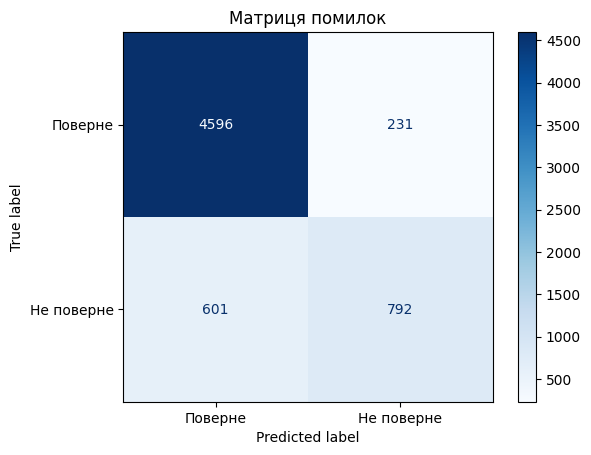

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Поверне', 'Не поверне'])
disp.plot(cmap='Blues')
plt.title('Матриця помилок')
plt.show()

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("МЕТРИКИ ЯКОСТІ МОДЕЛІ:")
print(f"Accuracy (Точність):    {accuracy:.3f}")
print(f"Precision (Влучність):  {precision:.3f}")
print(f"Recall (Повнота):       {recall:.3f}")
print(f"F1-score:               {f1:.3f}")

МЕТРИКИ ЯКОСТІ МОДЕЛІ:
Accuracy (Точність):    0.866
Precision (Влучність):  0.774
Recall (Повнота):       0.569
F1-score:               0.656


In [37]:
from sklearn.metrics import roc_curve, roc_auc_score
import plotly.graph_objects as go


fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])
auc = roc_auc_score(y_test, y_pred_proba[:, 1])


fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC (AUC = {auc:.3f})'))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'),
                        name='Випадковий класифікатор'))
fig.update_layout(
    title='ROC-крива',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    height=500
)
fig.show()

In [36]:
import numpy as np
feature_importance = pd.DataFrame({
  'feature': X.columns,
  'coefficient': model.coef_[0],
  'abs_coefficient': np.abs(model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

feature_importance

,feature,coefficient,abs_coefficient
5,loan_percent_income,1.318553,1.318553
17,loan_grade_D,0.812938,0.812938
3,loan_amnt,-0.546248,0.546248
18,loan_grade_E,0.477536,0.477536
8,person_home_ownership_OWN,-0.459162,0.459162
9,person_home_ownership_RENT,0.404043,0.404043
14,loan_intent_VENTURE,-0.400211,0.400211
10,loan_intent_EDUCATION,-0.326753,0.326753
20,loan_grade_G,0.309888,0.309888
19,loan_grade_F,0.269311,0.269311


In [ ]:
#Найбільше впливають loan_percent_income та loan_grade_D.Якщо оцінювати модель за  Recall  метрикою
#то модель трохи краща за випадковий результат,попри те ми маємо інші метрики ,які мають кращий результат
#AUC = 0.874 свідчить про те що модель доволі точна.


---

## Завдання 6: Оптимізація порогу та бізнес-аналіз (2 бали)

**Що потрібно зробити:**
1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.
2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.



In [41]:
thresholds = np.arange(0.35, 0.9, 0.05)
metrics_by_threshold = []

for threshold in thresholds:
    y_pred_custom = (y_pred_proba[:, 1] >= threshold).astype(int)

    metrics_by_threshold.append({
        'threshold': threshold,
        'precision': precision_score(y_test, y_pred_custom),
        'recall': recall_score(y_test, y_pred_custom),
        'f1': f1_score(y_test, y_pred_custom)
    })

metrics_df = pd.DataFrame(metrics_by_threshold)

# Візуалізація
fig = px.line(
    metrics_df.melt(id_vars='threshold'),
    x='threshold',
    y='value',
    color='variable',
    title='Метрики при різних порогах рішення',
    labels={'value': 'Значення метрики', 'threshold': 'Поріг'},
)
fig.show()

In [ ]:
#Оптимальний поріг який оптимізує точність 0.35 для цієї моделі.

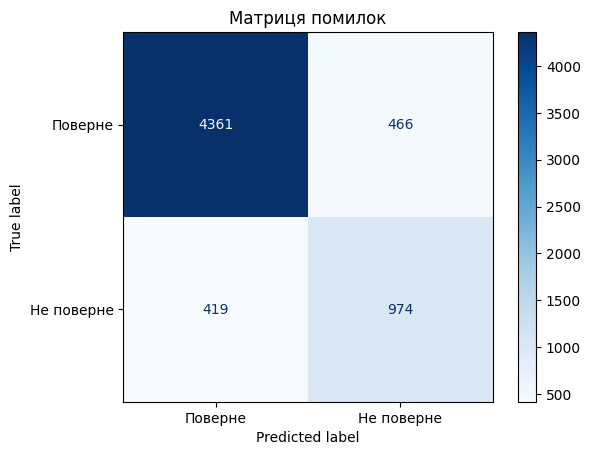

In [43]:
y_pred_opt = y_pred_proba[:,1]>=0.35
cm = confusion_matrix(y_test, y_pred_opt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Поверне', 'Не поверне'])
disp.plot(cmap='Blues')
plt.title('Матриця помилок')
plt.show()

In [ ]:
#Ми точніше класифікуєм хто не поверне ,але й більш помилково класифікуємо тих хто поверне.


---

## Завдання 7 (Опціональне): Покращення моделі та висновки (2 бали)

**Що потрібно зробити:**

На цих же даних навчіть DecisionTreeClassifier та RandomForestClassifier. Яка з трьох моделей дає найкращий результат на тестовому наборі?

Поріг класифікації можна для порівняння якостей моделей використовувати стандартний 0.5, або той, що ви виявили, як оптимальний на попередньому кроці.


In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Навчаємо альтернативні моделі
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    threshold = 0.35
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_pred_proba >= threshold).astype(int)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_pred_proba)
    })

results_df = pd.DataFrame(results).round(3)
print(results_df)

                 Model  Accuracy  Precision  Recall     F1    AUC
0  Logistic Regression     0.858      0.676   0.699  0.688  0.874
1        Decision Tree     0.884      0.752   0.716  0.734  0.872
2        Random Forest     0.917      0.854   0.761  0.805  0.930


In [ ]:
# Random Forest  model has the best predictivity score .

